# Curating COVID example data


Canadian HV.1 and JN.1 data was downloaded on 2026-02-02 from [ViruSeq Portal](https://virusseq-dataportal.ca/explorer?filters=%7B%22content%22%3A%5B%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1696132800000%7D%2C%22op%22%3A%22%3E%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.first_published_at%22%2C%22value%22%3A1704085199999%7D%2C%22op%22%3A%22%3C%3D%22%7D%2C%7B%22content%22%3A%7B%22fieldName%22%3A%22analysis.lineage_analysis.lineage_name%22%2C%22value%22%3A%5B%22HV.1%22%2C%22JN.1%22%2C%22JN.1.1%22%2C%22JN.1.10%22%2C%22JN.1.18%22%2C%22JN.1.19%22%2C%22JN.1.2%22%2C%22JN.1.22%22%2C%22JN.1.31%22%2C%22JN.1.39%22%2C%22JN.1.4%22%2C%22JN.1.4.5%22%2C%22JN.1.4.7%22%2C%22JN.1.41%22%2C%22JN.1.44%22%2C%22JN.1.45%22%2C%22JN.1.47.1%22%2C%22JN.1.5%22%2C%22JN.1.52%22%2C%22JN.1.55%22%2C%22JN.1.6%22%2C%22JN.1.60%22%2C%22JN.1.8%22%2C%22JN.1.8.3%22%2C%22JN.1.9%22%5D%7D%2C%22op%22%3A%22in%22%7D%5D%2C%22op%22%3A%22and%22%7D) by selecting all data submitted between 2023-10-01 and 2023-12-31 with lineage name equal to 'HV.1', 'JN.1' or starting with 'JN.1.'.



Import necessary packages


In [1]:
import os
import pandas as pd
import Bio.SeqIO
from tqdm import tqdm
import yaml

## Double checking data contains only HV.1 and JN.1 sequences
### Metadata

In [2]:
metadata = pd.read_csv('virusseq-search-export-2026-02-02/metadata.tsv',
    parse_dates=[ 'submission date', 'sample collection date'], sep='\t')
with open('sub_variants_map.yaml', 'r') as file:
    sub_variants_map = yaml.safe_load(file)
allowed_lineages = [item for sublist in sub_variants_map.values() for item in sublist]
metadata = metadata[metadata['lineage name'].isin(allowed_lineages)]

### Sequences


In [3]:
HV_1_and_JN1_sequences = []
for record in tqdm(Bio.SeqIO.parse('virusseq-search-export-2026-02-02/sequences.fasta',
    'fasta')):
    if record.id in metadata['fasta header name'].values:
        HV_1_and_JN1_sequences.append(record)
with open('HV_1_and_JN_1_sequences_unaligned.fasta', 'w') as file:
    Bio.SeqIO.write(HV_1_and_JN1_sequences, file, 'fasta')
file.close()

6721it [00:05, 1216.89it/s]


## Explore metadata

Counts of lineages

In [4]:
metadata['lineage name'].value_counts()

lineage name
HV.1         6300
JN.1          179
JN.1.1         80
JN.1.4         49
JN.1.2         47
JN.1.22        21
JN.1.31        10
JN.1.4.5        9
JN.1.9          5
JN.1.47.1       3
JN.1.19         2
JN.1.6          2
JN.1.5          2
JN.1.45         1
JN.1.8.3        1
JN.1.44         1
JN.1.41         1
JN.1.60         1
JN.1.10         1
JN.1.8          1
JN.1.52         1
JN.1.4.7        1
JN.1.55         1
JN.1.39         1
JN.1.18         1
Name: count, dtype: int64

How many JN.1 & all its sublineages

In [5]:
len(metadata[metadata['lineage name']!='HV.1'])

421

Collection date data for all HV.1.

In [6]:
metadata[metadata['lineage name']=='HV.1']['sample collection date'].describe()

count                          6300
mean     2023-10-28 06:09:08.571428
min             2023-08-15 00:00:00
25%             2023-10-14 00:00:00
50%             2023-11-01 00:00:00
75%             2023-11-14 00:00:00
max             2023-12-08 00:00:00
Name: sample collection date, dtype: object

Collection date data for all JN.1 and its sublineages.

In [7]:
metadata[metadata['lineage name']!='HV.1']['sample collection date'].describe()

count                           421
mean     2023-11-18 14:35:37.767221
min             2023-10-09 00:00:00
25%             2023-11-15 00:00:00
50%             2023-11-21 00:00:00
75%             2023-11-25 00:00:00
max             2023-12-04 00:00:00
Name: sample collection date, dtype: object

## Aligning and masking Sequences

Sequences will be aligned using Nextclade.

### Obtaining Reference genome

In [8]:
%%bash
source activate dev_beast_pype
nextclade dataset get --name 'nextstrain/sars-cov-2/wuhan-hu-1/orfs' --output-dir 'nextclade-sars-cov-2'

### Align Sequences

In [9]:
%%bash
source activate dev_beast_pype
nextclade run \
   --input-dataset nextclade-sars-cov-2 \
   --output-all=output/ \
   HV_1_and_JN_1_sequences_unaligned.fasta

### Post-Alignment checks

#### All from the JN.1 or HV.1.

In [10]:
nextclade_df = pd.read_csv('output/nextclade.tsv', sep='\t')
nextclade_df.Nextclade_pango.value_counts()


Nextclade_pango
HV.1         6296
JN.1          180
JN.1.1         79
JN.1.4         47
JN.1.2         47
JN.1.22        21
JN.1.4.5       11
JN.1.31        10
JN.1.9          5
HV.1.6          4
JN.1.47.1       3
JN.1.19         2
JN.1.6          2
JN.1.5          2
JN.1.32         1
JN.1.8.3        1
JN.1.44         1
JN.1.41         1
JN.1.60         1
JN.1.10         1
JN.1.8          1
JN.1.52         1
JN.1.4.7        1
JN.1.55.1       1
JN.1.39         1
JN.1.18         1
Name: count, dtype: int64

That is fine. 

#### Check coverage

In [11]:
nextclade_df.coverage.describe()

count    6721.000000
mean        0.987797
std         0.012645
min         0.900880
25%         0.987493
50%         0.992409
75%         0.994181
max         0.995920
Name: coverage, dtype: float64

<Axes: ylabel='Frequency'>

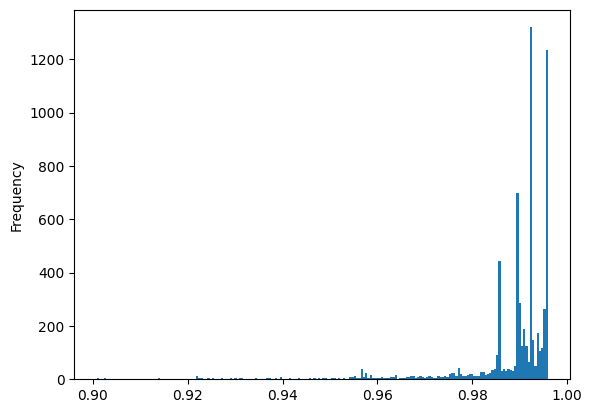

In [12]:
nextclade_df.coverage.plot.hist(bins=200)

## Increasing coverage to >= 0.98 and Saving Selection of HV.1 & JN.1 Sequences

In [13]:
sequences_ids_better_coverage = nextclade_df[nextclade_df.coverage>=0.98]['seqName'].values
metadata = metadata[metadata['fasta header name'].isin(sequences_ids_better_coverage)]
metadata.to_csv('HV_1_and_JN_1_metadata.csv', index=False)

In [14]:
selected_HV_1_and_JN1_sequences = []
for record in tqdm(Bio.SeqIO.parse('output/nextclade.aligned.fasta',
    'fasta')):
    if record.id in sequences_ids_better_coverage:
        selected_HV_1_and_JN1_sequences.append(record)
with open('HV_1_and_JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(selected_HV_1_and_JN1_sequences, file, 'fasta')
file.close()

6721it [00:04, 1607.91it/s]


## Putting JN.1 Sequences in there own dataset

In [15]:
JN1_metadata = metadata[metadata['lineage name']!='HV.1']
JN1_metadata.to_csv('JN_1_metadata.csv', index=False)


In [17]:
JN1_ids = JN1_metadata['fasta header name'].values
JN1_sequences = []

for record in tqdm(Bio.SeqIO.parse('HV_1_and_JN_1_sequences.fasta', 'fasta')):
    if record.id in JN1_ids:
        JN1_sequences.append(record)

5920it [00:01, 4529.99it/s]


In [18]:
len(JN1_sequences)

397

In [19]:
len(JN1_metadata)

397

In [20]:
with open('JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(JN1_sequences, file, 'fasta')
file.close()

## Putting HV.1 Sequences in there own dataset

In [21]:
HV1_metadata = metadata[metadata['lineage name']=='HV.1']
HV1_metadata.to_csv('HV_1_metadata.csv', index=False)


In [22]:
HV1_ids = HV1_metadata['fasta header name'].values
HV1_sequences = []

for record in tqdm(Bio.SeqIO.parse('HV_1_and_JN_1_sequences.fasta', 'fasta')):
    if record.id in HV1_ids:
        HV1_sequences.append(record)
with open('HV_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(HV1_sequences, file, 'fasta')
file.close()

5920it [00:03, 1516.52it/s]


### Trying to get under GitHubs file size limit (idealy 50 MiB, hard limit 100 Mib)

In [23]:
JN1_metadata['sample collection date'].describe()

count                           397
mean     2023-11-18 12:48:58.035264
min             2023-10-09 00:00:00
25%             2023-11-15 00:00:00
50%             2023-11-21 00:00:00
75%             2023-11-25 00:00:00
max             2023-12-04 00:00:00
Name: sample collection date, dtype: object

In [24]:
HV1_metadata['sample collection date'].describe()

count                          5523
mean     2023-10-27 19:28:34.937534
min             2023-08-15 00:00:00
25%             2023-10-12 00:00:00
50%             2023-10-31 00:00:00
75%             2023-11-13 00:00:00
max             2023-12-08 00:00:00
Name: sample collection date, dtype: object

### Downsampling HV.1 sequences to 500 sequences

In [25]:
from beast_pype.path_utils import path_to_workflow_modules
from beast_pype.nb_utils import execute_notebook
workflow_modules_path = path_to_workflow_modules()

In [26]:
iq_tree_params = {
    'save_dir': os.getcwd(),
    'fasta_path': 'HV_1_sequences.fasta',
    'max_threads':15,
    'tree_dir_name':'HV_1_iqtree',
    'kernel_name':'dev_beast_pype',
    'seed':42
}

execute_notebook(f'{workflow_modules_path}/Phase-2i-and-2iii-IQTree-Building.ipynb',
                 'HV1_IQ_tree_building.ipynb', 
                 parameters=iq_tree_params,
                 progress_bar=True,
                 nest_asyncio=True)
execute_notebook(f'{workflow_modules_path}/Phase-2i-and-2iii-IQTree-Correction.ipynb', 'HV1_IQ_tree_correction.ipynb', 
                 parameters=iq_tree_params,
                 progress_bar=True,
                 nest_asyncio=True, 
                 kernel_name='dev_beast_pype')

Translator for 'bash' language does not support parameter introspection.
Passed unknown parameter: save_dir
Passed unknown parameter: fasta_path
Passed unknown parameter: max_threads
Passed unknown parameter: tree_dir_name
Passed unknown parameter: kernel_name
Passed unknown parameter: seed


Executing:   0%|          | 0/7 [00:00<?, ?cell/s]

Passed unknown parameter: max_threads
Passed unknown parameter: kernel_name
Passed unknown parameter: seed


Executing:   0%|          | 0/5 [00:00<?, ?cell/s]

In [27]:
tree_time_and_downsampling_params = {
    'save_dir': os.getcwd(),
    'fasta_path': 'HV_1_sequences.fasta',
    'metadata_path': 'HV_1_metadata.csv',
     'sample_id_field':'fasta header name',
     'collection_date_field':'sample collection date',
    'tree_dir_name':'HV_1_iqtree',
    'seed':42,
    'downsample_to':500
}
execute_notebook(f'{workflow_modules_path}/Phase-2ii-and-2iv-TreeTime-and-Downsampling.ipynb',
                 'HV1_tree_time_and_downsampling.ipynb',
                 parameters=tree_time_and_downsampling_params ,
                 progress_bar=True,
                 nest_asyncio=True, 
                 kernel_name='dev_beast_pype')

Executing:   0%|          | 0/16 [00:00<?, ?cell/s]

### Merging downsampled HV.1 sequences with JN.1 sequences and saving final datasets
#### Metadata

In [28]:
downsampled_HV1_metadata = pd.read_csv('downsampled_metadata.csv',parse_dates=[ 'submission date', 'sample collection date'])
test_metadata = pd.concat([downsampled_HV1_metadata, JN1_metadata])
test_metadata.to_csv('test_HV_1_and_JN_1_metadata.csv', index=False)

In [29]:
from itertools import chain
JN1_sequences = list(Bio.SeqIO.parse('JN_1_sequences.fasta', 'fasta'))
downsampled_HV1_sequences = list(Bio.SeqIO.parse('downsampled_sequences.fasta', 'fasta'))

test_sequences = chain(JN1_sequences, downsampled_HV1_sequences)
with open('test_HV_1_and_JN_1_sequences.fasta', 'w') as file:
    Bio.SeqIO.write(test_sequences, file, 'fasta')

In [30]:
downsampled_HV1_metadata['sample collection date'].describe()


count                           500
mean     2023-10-26 16:39:21.600000
min             2023-09-04 00:00:00
25%             2023-10-09 00:00:00
50%             2023-11-02 00:00:00
75%             2023-11-09 06:00:00
max             2023-12-06 00:00:00
Name: sample collection date, dtype: object